# Final Project: Student Performance Factors Dataset

## Problem Statement and Hypothesis

#### **Problem:** 
>Educators want to better understand which factors influence student academic performance. By identifying the variables that most strongly affect exam scores, schools can develop strategies that improve student outcomes.

#### **Hypothesis:** 
> \"Attendance, hours studied, and previous academic performance will be the strongest predictors of a student's final exam score, compared to environmental or socioeconomic variables.\"

## Data Sourcing (KaggleHub)

#### The Dataset used for this project is...
> ***"Student Performance Factors Dataset"*** dataset, sourced from [Kaggle] (http://www.kaggle.com)
>>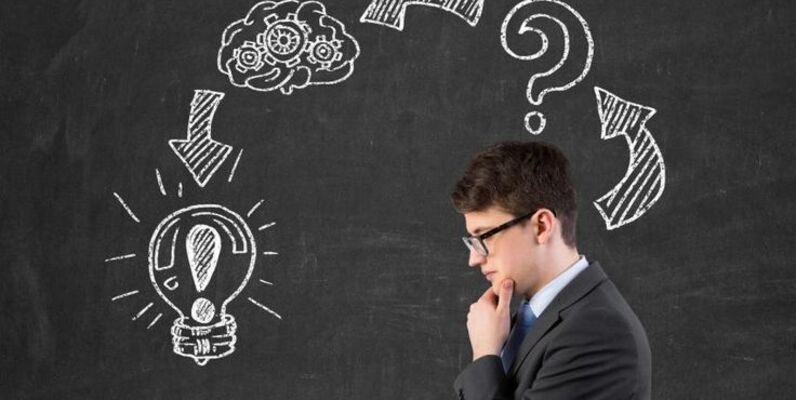
>>> ###### created by **Muhammad Ahmad**.

#### **Why We Chose it**
> This dataset contains a mixture of academic, social, and environmental factors that may influence student performance. Because the dataset contains both categorical and numerical variables, it allows for meaningful exploratory analysis and predictive modeling.


#### **The Libraries**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

#### **Initial Look at Data -->**

In [7]:
# Load the CSV
df = pd.read_csv("StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [8]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [9]:
# double checking the counts of rows and columns are correct. Also summary of all columns
print (df.shape)
df.info()

(6607, 20)
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical

## Data Cleaning and Manipulation

1. **Handle the missing data:**
   1. Identify Nulls
   2. Use Imputation
      >fill gaps with mean/mode to fix them
2. **Encoding:**
   1. Convert text colums like parental_involvement (low,medium,high) into numbers (o,1,2) so the model can read them.
      > change categorical data into numerical data
3. **Filtering:**
   1. Remove any outliers or unnecssary colums that don't help your prediction


### 1. Identifying and Handeling the Nulls
>> By using print( df.isnull().sum()) we can see that there are missing values in the columns; "Teacher_quality" , "Parental_Education_Level", and "Distance_From_Home".
>>once inspected we need to access whether to drop or fill the missing values

In [10]:
# checking for missing values
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


### Visualizing the null values in the dataset
> we used a missing values heatmap below to visualize __null__ values in the dataset.
> As you can see the map only shows small scattered missing values across several columns. This tell us that the missing data is minimal and won't significantly impact our analysis if we were to drop the null values. 

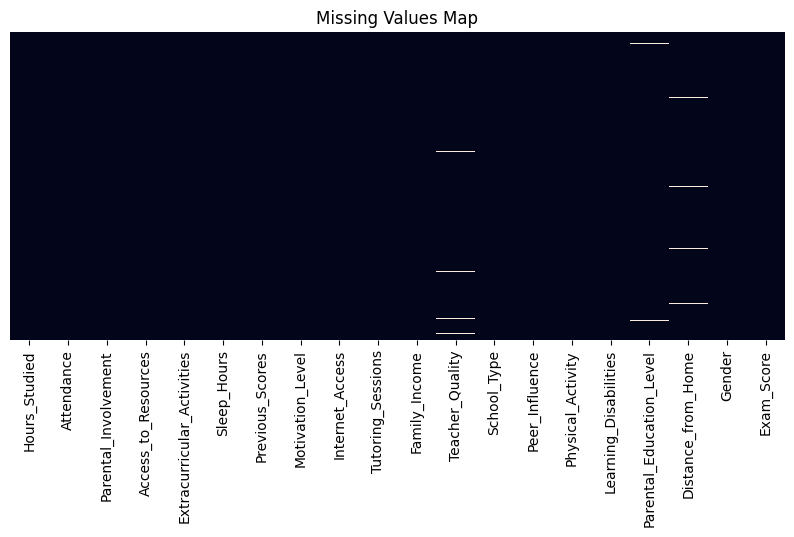

In [11]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Map")
plt.show()

In [12]:
## Although there are some missing values in the dataset, they are not significant. 
## We'd rather  drop the rows with missing values for simplicity, than impute them.
## Creating a new variable to see how many rows we lost by dropping the missing values

df_clean = df.dropna()

### 2. Verfying Missing Values Were Removed


In [13]:
## Verify the results
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Rows lost: {len(df) - len(df_clean)}")

Original rows: 6607
Cleaned rows: 6378
Rows lost: 229


In [14]:
#Check again for missing values after dropping
print(df_clean.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [15]:
## Checking to see the percentage of missing values in each column to confirm that dropping them is reasonable
## divide the sum of missing values by the total number of rows and then multiply by 100 to get the percentage
print("\nMissing Values Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)


Missing Values Percentage:
Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


In [16]:
## now we want to check the total percentage of missing values in each row to confirm that dropping them is reasonable
print("\nMissing Values Percentage per Row:")
missing_percentage_row = (df.isnull().sum(axis=1) / df.shape[1]) * 100
print(missing_percentage_row)



Missing Values Percentage per Row:
0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6602    0.0
6603    0.0
6604    0.0
6605    0.0
6606    0.0
Length: 6607, dtype: float64


In [17]:
# df.isnull() --> to find the missing values
# any(axis=1) --> to check if there are any missing values in each row
# sum() --> to count the number of rows with missing values
# We then divided it to convert the total to a percentage

rows_with_missing_values = (df.isnull().any(axis=1)).sum()
total_rows = len(df)
percent_rows_missing = (rows_with_missing_values / total_rows) * 100

print(percent_rows_missing)

3.466020886938096


#### Takeaway after cleaning...
> Approximately 3.4% of the rows contain missing values and were removed. This is a small portion of the dataset; therefore, i gathered that removing these rows would significantly influence my analysis and am comfortable with my decision to proceed with removing them

### 2. **Encoding:**
> Convert text colums like parental_involvement (low,medium,high) into numbers (0,1,>> 2) so the model can read them.
>>-->Change categorical data into numerical data


In [18]:
## pd.get_dummies() --> used to convert categorical variables to numerical variables by creating dummy/indicator variables for each category.
## drop_first=True --> to avoid the dummy variable trap by dropping the first category of each variable

In [19]:
df_clean = pd.get_dummies(df_clean, drop_first=True)

#Preview the new columns
print(df_clean.columns)
df_clean

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score',
       'Parental_Involvement_Low', 'Parental_Involvement_Medium',
       'Access_to_Resources_Low', 'Access_to_Resources_Medium',
       'Extracurricular_Activities_Yes', 'Motivation_Level_Low',
       'Motivation_Level_Medium', 'Internet_Access_Yes', 'Family_Income_Low',
       'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium',
       'School_Type_Public', 'Peer_Influence_Neutral',
       'Peer_Influence_Positive', 'Learning_Disabilities_Yes',
       'Parental_Education_Level_High School',
       'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate',
       'Distance_from_Home_Near', 'Gender_Male'],
      dtype='str')


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,7,76,1,2,68,False,False,False,...,True,True,False,True,False,True,False,False,True,False
6603,23,76,8,81,3,2,69,False,False,False,...,False,True,False,True,False,True,False,False,True,False
6604,20,90,6,65,3,2,68,False,True,True,...,True,True,False,False,False,False,True,False,True,False
6605,10,86,6,91,2,3,68,False,False,False,...,True,False,False,True,False,True,False,False,False,False


In [20]:
# Confirm that all the data types of the columns are numerical
df_clean.dtypes
print(df_clean.dtypes)

Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_Low                  bool
Parental_Involvement_Medium               bool
Access_to_Resources_Low                   bool
Access_to_Resources_Medium                bool
Extracurricular_Activities_Yes            bool
Motivation_Level_Low                      bool
Motivation_Level_Medium                   bool
Internet_Access_Yes                       bool
Family_Income_Low                         bool
Family_Income_Medium                      bool
Teacher_Quality_Low                       bool
Teacher_Quality_Medium                    bool
School_Type_Public                        bool
Peer_Influence_Neutral                    bool
Peer_Influenc

In [21]:
# Not neccessary but i want to further convert the data types so they are all integers for simplicity
# i want to view the change as well so i will print the data types again after converting them to integers
df_clean = df_clean.astype(int)
print(df_clean.dtypes)

Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_Low                 int64
Parental_Involvement_Medium              int64
Access_to_Resources_Low                  int64
Access_to_Resources_Medium               int64
Extracurricular_Activities_Yes           int64
Motivation_Level_Low                     int64
Motivation_Level_Medium                  int64
Internet_Access_Yes                      int64
Family_Income_Low                        int64
Family_Income_Medium                     int64
Teacher_Quality_Low                      int64
Teacher_Quality_Medium                   int64
School_Type_Public                       int64
Peer_Influence_Neutral                   int64
Peer_Influenc

In [22]:
print("Dataset shape after encoding:",df_clean.shape)
print("Vs original shape:", df.shape)
print("After cleaning and encoding, we have",df_clean.shape[0] - df.shape[0], "fewer rows and", df_clean.shape[1] - df.shape[1], "more columns.")
## Note for self: the increase in columns is due to the creation of dummy variables for the categorical features. The decrease in rows is due to dropping rows with missing values.

Dataset shape after encoding: (6378, 28)
Vs original shape: (6607, 20)
After cleaning and encoding, we have -229 fewer rows and 8 more columns.


In [23]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6378 non-null   int64
 1   Attendance                             6378 non-null   int64
 2   Sleep_Hours                            6378 non-null   int64
 3   Previous_Scores                        6378 non-null   int64
 4   Tutoring_Sessions                      6378 non-null   int64
 5   Physical_Activity                      6378 non-null   int64
 6   Exam_Score                             6378 non-null   int64
 7   Parental_Involvement_Low               6378 non-null   int64
 8   Parental_Involvement_Medium            6378 non-null   int64
 9   Access_to_Resources_Low                6378 non-null   int64
 10  Access_to_Resources_Medium             6378 non-null   int64
 11  Extracurricular_Activities_Yes         6378 no

## Exploratory Data Analysis (EDA)

##### Workflow:
1. Data Overview
2. Target Variable Analysis
4. Bivariate Analysis (Feature vs Target)
5. Correlation Analysis
6. Outlier Detection
7. Feature Importance Exploration
8. Observations


In [24]:
## 1. Dataset Overview:
df_clean.shape
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6378 non-null   int64
 1   Attendance                             6378 non-null   int64
 2   Sleep_Hours                            6378 non-null   int64
 3   Previous_Scores                        6378 non-null   int64
 4   Tutoring_Sessions                      6378 non-null   int64
 5   Physical_Activity                      6378 non-null   int64
 6   Exam_Score                             6378 non-null   int64
 7   Parental_Involvement_Low               6378 non-null   int64
 8   Parental_Involvement_Medium            6378 non-null   int64
 9   Access_to_Resources_Low                6378 non-null   int64
 10  Access_to_Resources_Medium             6378 non-null   int64
 11  Extracurricular_Activities_Yes         6378 no

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
count,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,...,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,7.034964,75.066165,1.495296,2.972719,67.252117,0.202415,0.509721,0.199749,...,0.599875,0.695202,0.391188,0.400282,0.104735,0.495296,0.200690,0.304327,0.595955,0.578238
std,5.985460,11.550723,1.468033,14.400389,1.233984,1.028926,3.914217,0.401831,0.499945,0.399843,...,0.489962,0.460358,0.488055,0.489994,0.306236,0.500017,0.400548,0.460158,0.490745,0.493880
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Takeaway from analysis:
- Every column has the same count which confirms there are no missing values

- On average, students studied approximately 20hours, maintained roughly 80% attendance, and slept on average a total of 7 hours per night. This suggest a relatively balanced study and lifestyle habits across the dataset

- To add, the average previous academic score (~75%) is noticeably higher than the final exam score (~67%). This suggest that students performed worse on the final exam in comparision. 

- Based on the quartile stats we observed that exam scores are relatively concentrated between 65-69. This tell us that most students scored close to the average exam score

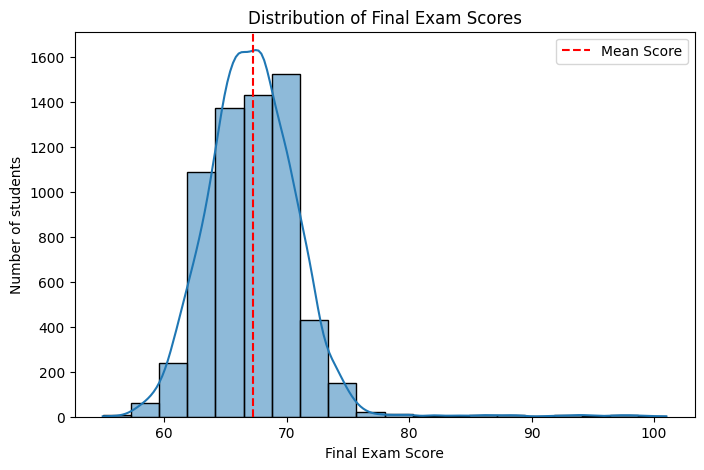

In [25]:
#Visual of the distribution of the target variable (final exam grade)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Exam_Score'], bins=20, kde=True)
plt.title('Distribution of Final Exam Scores')
plt.xlabel('Final Exam Score')
plt.ylabel('Number of students')
plt.axvline(df_clean["Exam_Score"].mean(), color='red', linestyle='--', label='Mean Score')
plt.legend()
plt.show()

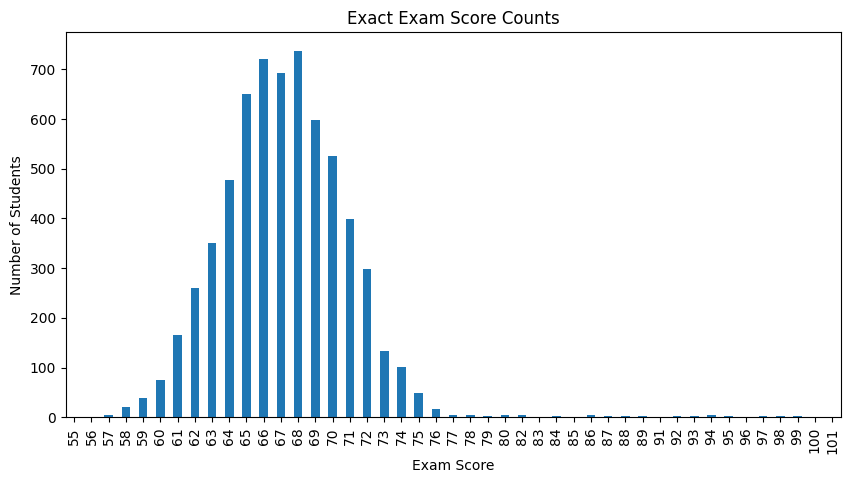

In [26]:
# We want to see the exact counts of each score in the dataset, so we will create a bar chart to visualize it. This will help us understand if there are any scores that are more common than others, and if there are any outliers in the data.
# We will use the value_counts() function to get the counts of each score, and then plot it using a bar chart.
# We will also sort the index of the value counts to ensure that the scores are displayed in order on the x-axis of the bar chart.
# This will give us a clear visual representation of the distribution of the exam scores in the dataset, and help us identify any patterns or trends in the data.

score_counts = df_clean["Exam_Score"].value_counts().sort_index()

plt.figure(figsize=(10,5))
score_counts.plot(kind="bar")

plt.title("Exact Exam Score Counts")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

#### Correlation Heatmap
> I want to view the correlation coefficient (r) between variables. My Goal is to visualize and interpret what factors influence Exam_Score the most.

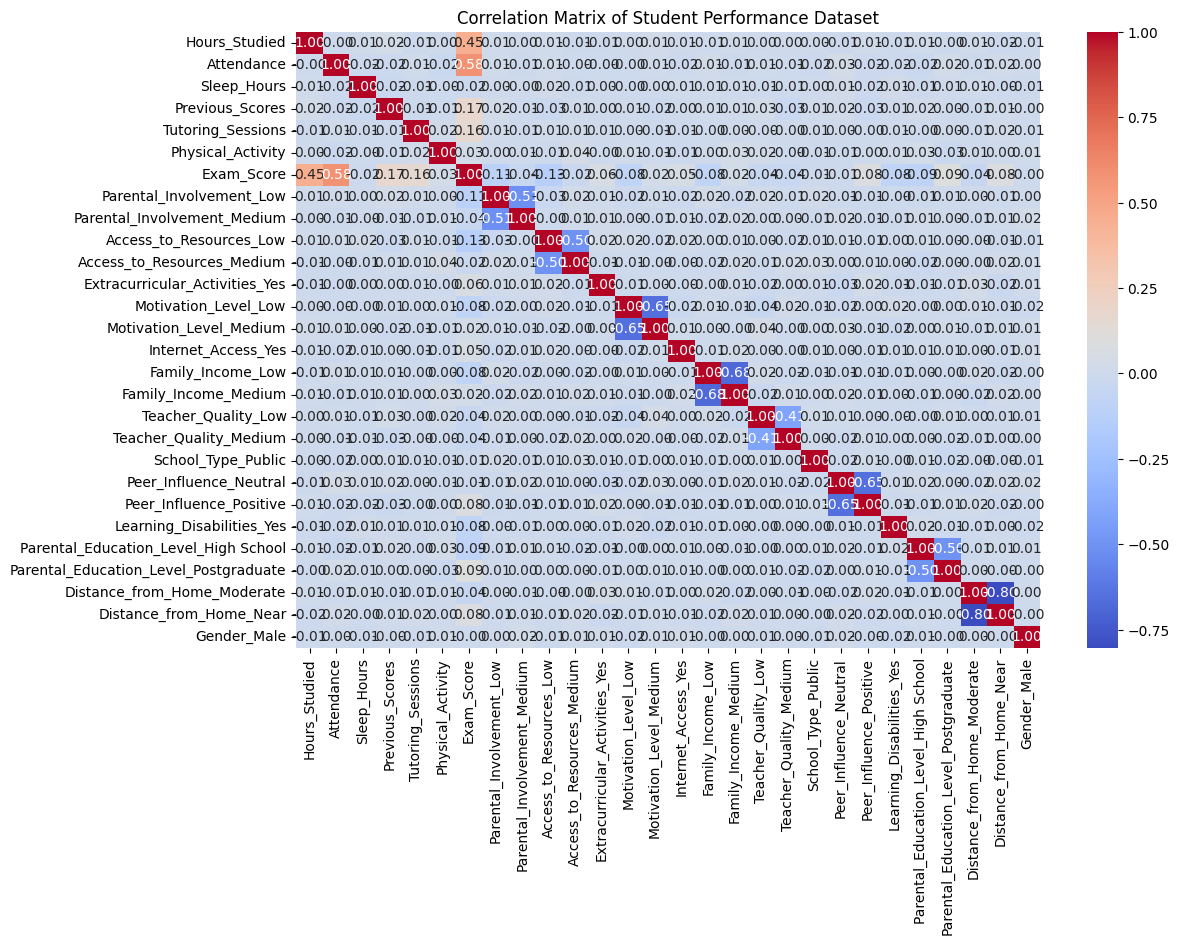

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Student Performance Dataset")
plt.show()

#### HeatMap Correlation
> Side by side view (removed coefficients so the map looks less clustered)

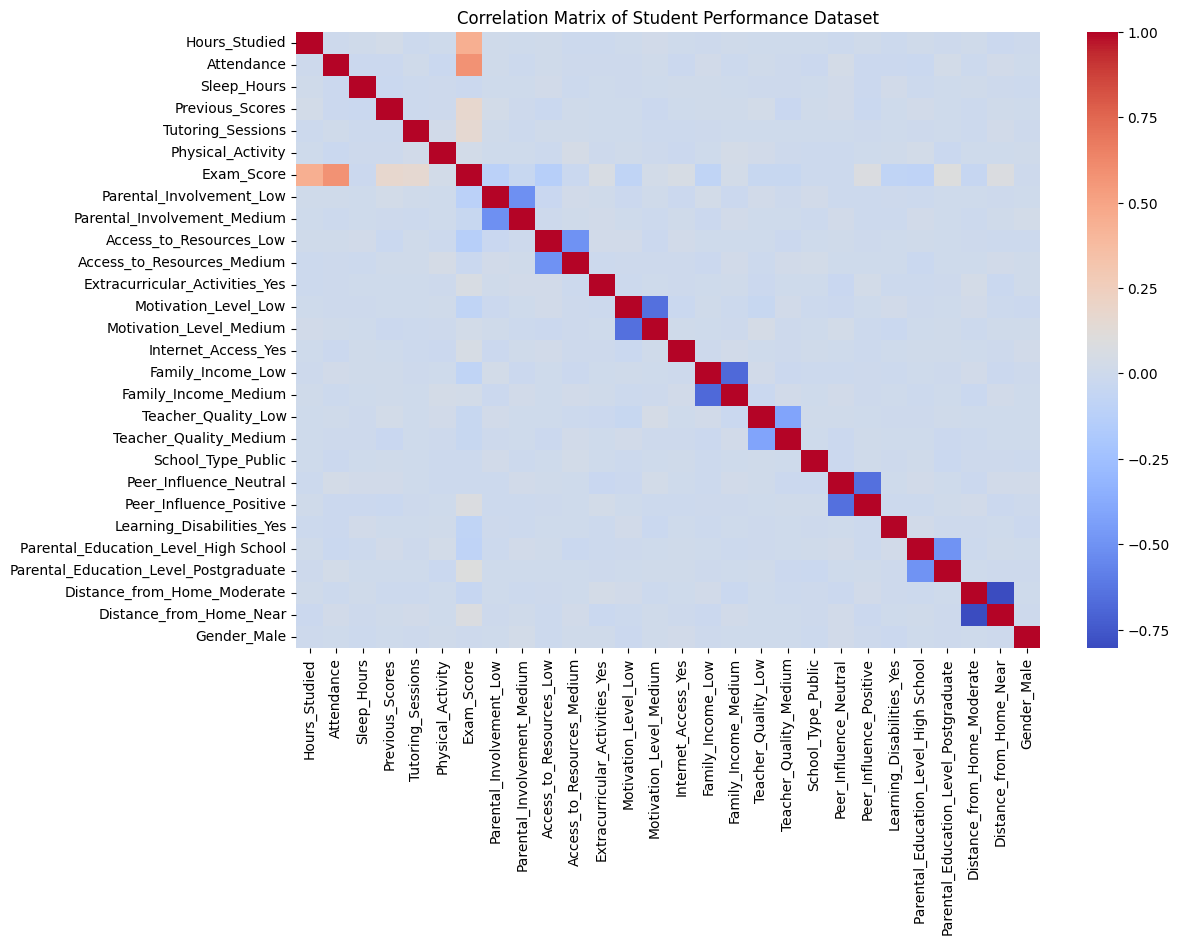

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.corr(),
    annot=False,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Student Performance Dataset")
plt.show()

##### Analysis:
> Exam scores show the strongest positive correlations with hours studied, attendance, and previous scores. Among these variables, hours studied has the strongest relationship with exam performance, suggesting that students who study more hours tend to achieve higher exam scores. Attendance also shows a moderate positive relationship with exam scores, indicating that regularly attending classes may contribute to better academic performance. Previous scores have a weaker correlation but may still provide some predictive value for student outcomes.

Correlations
* Hours Studied = 0.58
    - Strongest relationship
    - More study time --> higher exam score
* Attendance = 0.45
    - Moderate effect
    - Attending classes regularly helps performance
* Previous Scores = 0.17
    - weakest correlation
    - Tells us that although there is a positive correlation, it isn't high.
    - Past performance has some influence but it's not a strong predictor

#### <u>Regression Plot</u>
> To further examine the relationships identified in the correlation heatmap, We decided to create regression plots to help visualize the relationship between exam scores and the key predictors observed in the heatmap. The plot helps illustrate the strength and direction of the relationships between the variables.

__BreakDown__
* __y = Target variable__
* __x = predictor variable__ 
    - Hours studied
    - Attendance
    - Previous scores
* __m = slope (strength of relationship)__
* __b = intercept__

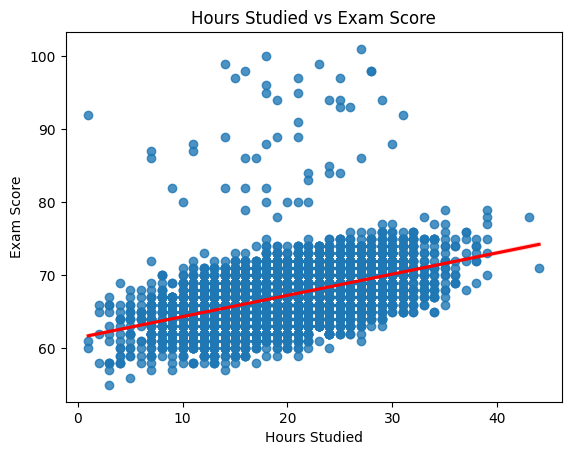

In [29]:
sns.regplot(
    x="Hours_Studied", 
    y="Exam_Score", 
    data= df_clean,
    line_kws={"color": 'red'}
            )

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

> This regression plot shows a clear positive relationship between hours studied and exam scores. Students who study more than hours tend to achieve higher exam scores.

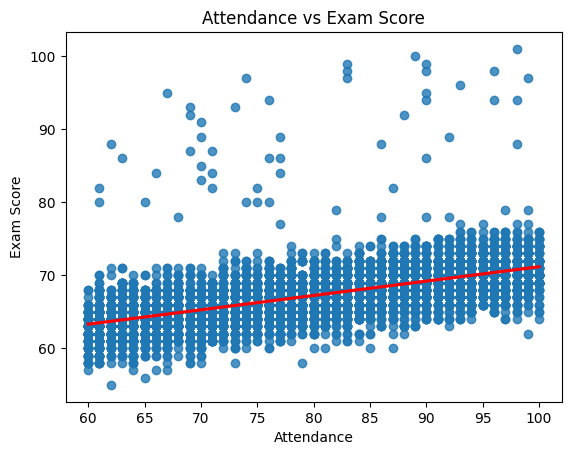

In [30]:
sns.regplot(
    x="Attendance", 
    y="Exam_Score", 
    line_kws={"color": 'red'},
    data=df_clean)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.show()

> This regression plot shows a moderate positive relationship between attendance and exam scores, suggesting that students who attend classes more frequently tend to perform better

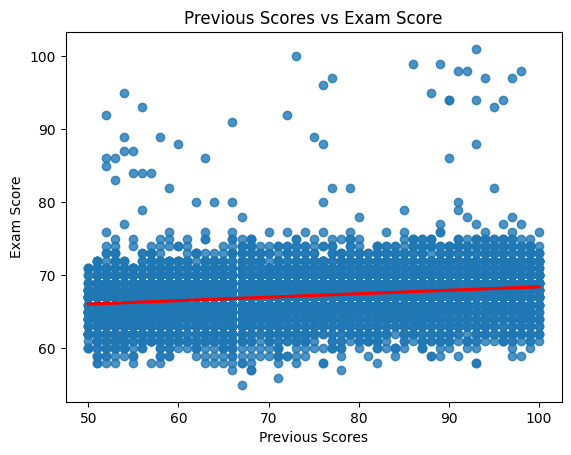

In [31]:
sns.regplot(
    x="Previous_Scores", 
    y="Exam_Score", 
    line_kws={"color": 'red'},
    data=df_clean)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")

plt.show()

>The relationship between previous scores and exam scores appears weaker compared to hours studied and attendance, but there is still a slight positive trend.

### Key Findings from Exploratory Data Analysis (EDA)

At the beginning of this analysis, we assumed that __previous academic scores__ would be the strongest predictor of a student's final exam score. However, after conducting exploratory data analysis using <u>correlation heatmaps</u> and <u>regression plots</u>, the results revealed a different pattern.

* The analysis showed that __Hours Studied__ has the strongest positive relationship with exam scores. This suggests that the amount of time students dedicate to studying plays the most significant role in determining their final performance.

* __Attendance__ was found to be the second most influential factor, indicating that regularly attending classes may contribute positively to student outcomes.

* Although **Previous Scores** still show a positive relationship with exam performance, the correlation is weaker than initially expected.

Overall, the findings suggest that **current study habits and engagement (hours studied and attendance)** have a stronger impact on exam performance than past academic results.

### Transition to Predictive Modeling

In the following section, we will implement a **Linear Regression model** to evaluate how well the features can predict a student's final exam score. This model will allow us to quantify the influence of each variable and assess the overall predictive performance of the dataset.

## Data Modelling

<u>Goal:</u>
- Our goal in this section is to build a predictive model that estimates a student's exam score based on the available features in the dataset. Using the relationships identified during EDA, we will train a Linear Regression model to determine how well these variables can predict student performance.

<u>Modelling Steps:</u>
1. Feature Selection
2. Train-Test Split
3. Model

<u>Target variable </u>
* __target variable =__ Exam_score
* __predictor variable =__ All features used to predict exam performance

#### Feature Selection
To build the model, we first separated the predictor variables (features) from the target variable.

In [42]:
# x = predictor variables (all columns except the target variable)
# y = target variable (Exam_Score)
X = df_clean.drop("Exam_Score", axis=1)
y = df_clean["Exam_Score"]

#### Train Test Split:
* We wanted to give the model enough data to learn patterns; while, still having data to properly test the model. We also wanted to ensure that we get the same split everytime.

* We used an 80/20 split because it allows the model to learn from most of the data while still keeping a portion of the dataset unseen so we can properly evaluate how well the model would do when presented with new data

* random_state=42 ensures we get the same split everytime the code runs

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Training the Model

We selected a **Linear Regression** model because our target variable contains continuous numerical values. Linear regression is designed to predict continuous outcomes by modeling the relationship between the input features and the target variable.

Another reason we chose linear regression is because it provides easily interpretable results. The model assigns a coefficient (weight) to each feature, which allows us to clearly see how much each feature affects our target. This helps us understand the relative importance and direction of influence each feature has on the target variable.

Because our goal is not only prediction but also understanding how the features impact the outcome, linear regression is an appropriate and interpretable starting model.

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


>During training, the model learns the relationship between the predictor variables and the target variable by estimating coefficients that minimize prediction error.

#### Making Predictions

After training the model, predictions were generated using the test dataset. The `predict()` function applies the learned linear regression equation to the unseen test data to estimate the target values.

We also examined the model's **intercept** and **coefficients**, which were learned during the training process. These values help us understand how each feature contributes to the model’s predictions.

- The **intercept** represents the predicted value of the target variable when all feature values are zero.
- The **coefficients** represent the strength and direction of the relationship between each feature and the target variable.

Positive coefficients indicate that as the feature increases, the predicted value also increases, while negative coefficients indicate an inverse relationship.

In [35]:
# Generating predictions on the training model
y_pred = model.predict(X_test)

### Predicted Visualization
__Actual vs Predicted__

To evaluate how well the model performs, we compare the predicted exam scores with the actual exam scores from the testing dataset.

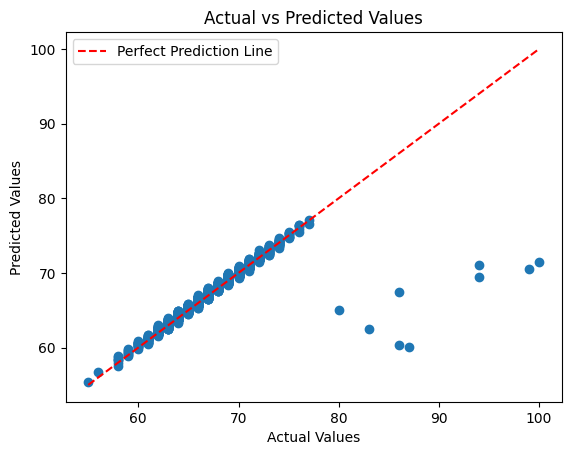

In [38]:
# testing to see if our model is good by plotting the actual vs predicted values. If the points are close to a straight line, then the model is performing well.
plt.scatter(y_test, y_pred) 
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         color='red', 
         linestyle='--', 
         label='Perfect Prediction Line')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.legend()
plt.show()

#### Model Performance Visualization

To better understand the model’s performance, we visualized the relationship between the actual target values and the predicted values generated by the model.

In this scatter plot, the x-axis represents the actual values from the test dataset, while the y-axis represents the predicted values from the model. If the model performs well, the points should cluster closely around a straight line, indicating that the predictions closely match the true values.

##### Interpretation of prediction plot...
The scatter plot shows that most predicted values closely follow the ideal prediction line, indicating that the model performs well for the majority of observations. This suggests that the selected features are able to explain a significant portion of the variation in exam scores.

However, the model tends to underpredict higher exam scores. For students with very high actual scores, the predicted values are noticeably lower than the true values. This suggests that additional factors not included in the model may influence higher-performing students.

> The model's coefficients are lower than expected because these outliers (red dots) achieved high scores regardless of their study time, which skewed the statistical impact of the features

## Model Validation

In [39]:
r2_score(y_test, y_pred)

0.7314386522127074

#### Model Performance (R² Score)

The model achieved an R² score of approximately 0.73. This indicates that the model explains about 73% of the variance in the exam scores using the selected features.

This suggests that the chosen predictors (hours studied, attendance, and previous scores) provide a strong explanation of student performance, although other factors not included in the dataset may also influence exam outcomes.

In [40]:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")


--- Model Performance ---
R2 Score: 0.7314
Mean Absolute Error: 0.4873
Root Mean Squared Error: 2.0429


#### Residual Plot
: Checking to see if our model's errors are random
* We want to determine whether the linear regression model is appropriate.
* Confirming if the residuals are randomly scattered around zero without a clear pattern. This tells us that our model captures the underlying relationship in the data

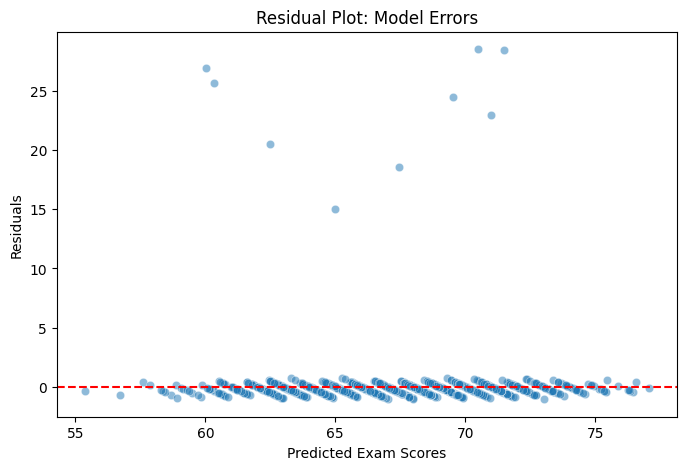

In [53]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Exam Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot: Model Errors")

plt.show()

: The residual plot shows that the prediction errors are scattered around zero without a clear pattern. This suggests that the linear regression model is reasonably appropriate for modeling the relationship between the predictor variables and exam scores.
> if the residual plot showed a curve, funnel, or systematic pattern, that would indicate the "clear pattern" we are testing aginst. 
Plot shows
1. Most residuals near 0 (actual - predicted)
2. No curve/funnel/systematic pattern
3. only a few outliers

### Feature Importance

The coefficients of a linear regression model represent how much each feature influences the predicted exam score. Larger absolute coefficient values indicate a stronger effect on the prediction.

In [36]:
# View the intercept and coefficients of the model to understand the relationship between the features and the target variable
model.intercept_ 
model.coef_

array([ 0.29583382,  0.19868938, -0.01282938,  0.04851359,  0.48277682,
        0.20022405, -2.01234139, -1.03853331, -2.05032244, -1.01082453,
        0.56672263, -1.10729809, -0.59888074,  0.9006084 , -1.14852255,
       -0.62083425, -1.05051238, -0.60615018,  0.04895936,  0.56186729,
        1.01488049, -0.87048418, -0.47620465,  0.52157639,  0.30496393,
        0.84182865, -0.01080161])

In [56]:
# I want to visually view the coefficients of the model to understand which features have the most impact on the target variable (Exam_Score).
coef_df= pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

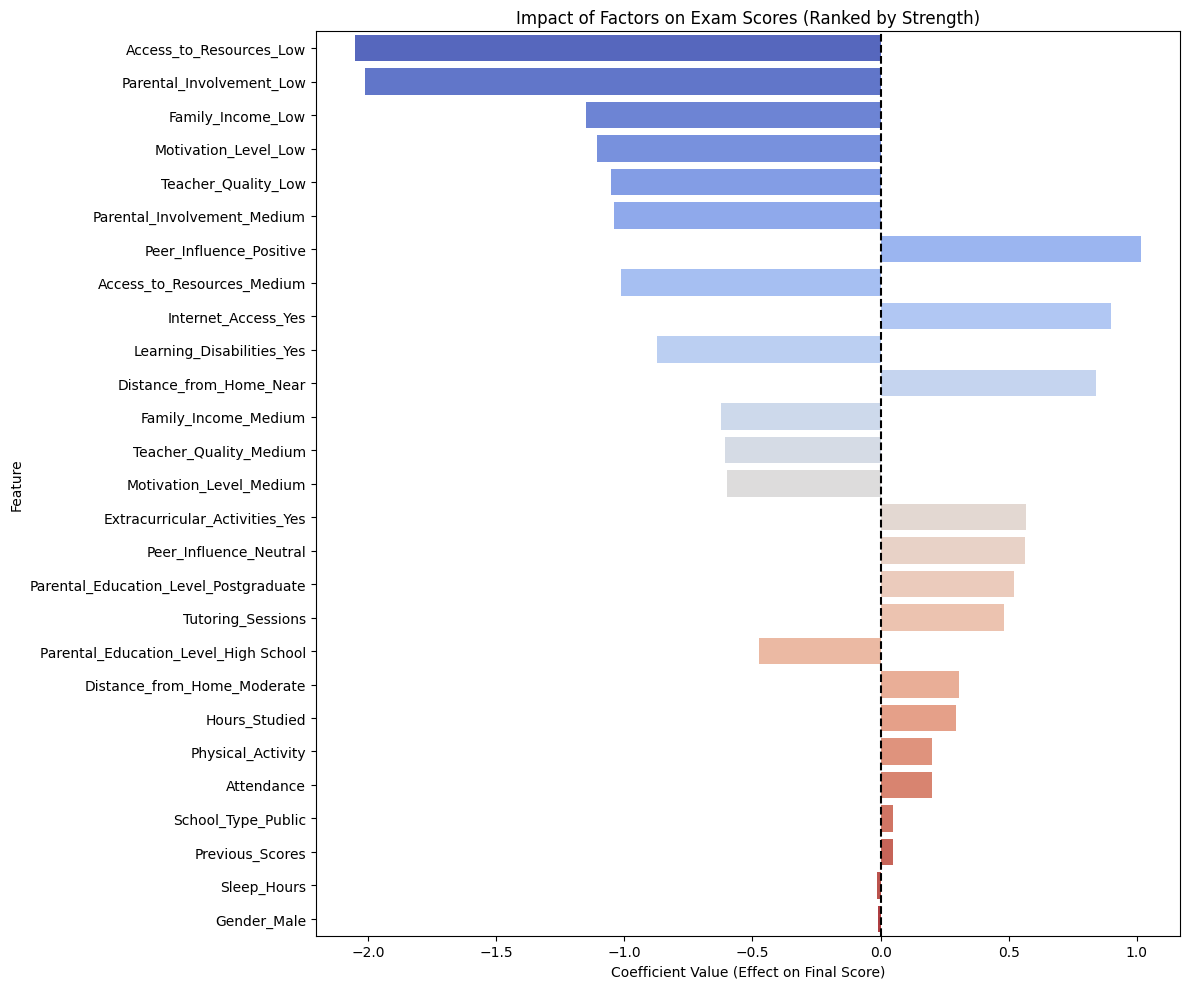

In [55]:
# 2. Add Absolute Value to sort by "Strength" (regardless of +/-)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# 3. Sort by strength descending to have the strongest factors at the top of the plot
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

# 4. Plotting
plt.figure(figsize=(12, 10))
# Using 'Coefficient' for the X-axis shows the direction (Positive/Negative)
# Using the sorted 'coef_df' ensures the strongest are at the top
sns.barplot(x="Coefficient", y="Feature", data=coef_df, palette="coolwarm", hue="Feature" , legend=False)

plt.title("Impact of Factors on Exam Scores (Ranked by Strength)")
plt.xlabel("Coefficient Value (Effect on Final Score)")
plt.ylabel("Feature")

# Add a vertical line at 0 to clearly separate positive/negative impact
plt.axvline(0, color='black', lw=1.5, ls='--')

plt.tight_layout()
plt.show()


#### Outlier Investigation
* This section examines outliers where the model's predictions differ significantly from the actual exam scores in order to understand unusual patterns that may have affected the model’s accuracy.

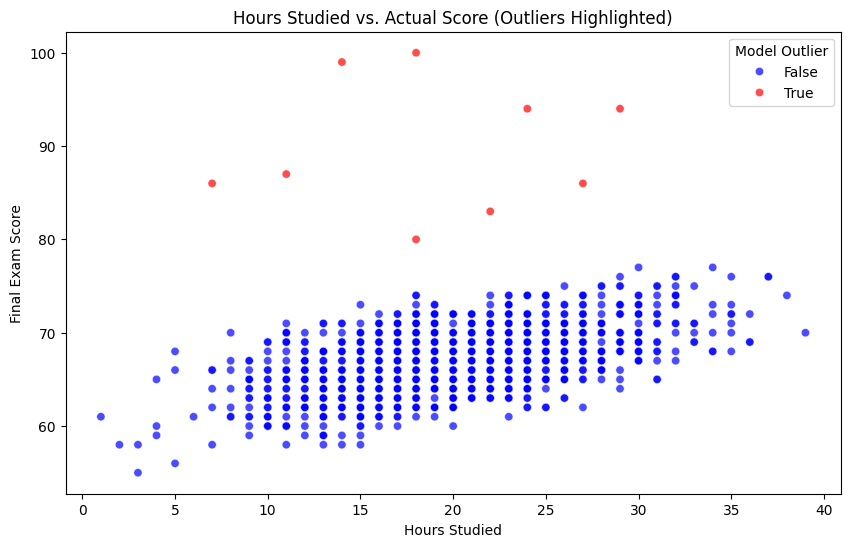

In [46]:
# 1. Identify the Outliers (from residual plot)
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Residual'] = y_test - model.predict(X_test)

#Checking to see how many outliers we have in the dataset by counting the number of rows where the residual is greater than 10
results_df['Is_Outlier'] = results_df['Residual'] > 10 

#Plot Hours Studied vs Score, highlighting the outliers
plt.figure(figsize=(10,6))
sns.scatterplot(data=results_df, x='Hours_Studied', y='Actual', 
                hue='Is_Outlier', palette={True: 'red', False: 'blue'}, alpha=0.7)

plt.title("Hours Studied vs. Actual Score (Outliers Highlighted)")
plt.xlabel("Hours Studied")
plt.ylabel("Final Exam Score")
plt.legend(title="Model Outlier")
plt.show()


#### Cross Validation

* As a final validation step, we performed 5-fold cross-validation to ensure that the model's performance was consistent across different subsets of the dataset.

* The results produced an average R² score of approximately 0.72, which is very close to the R² score obtained from the original train-test split. This confirms that the model generalizes well and that its performance is not dependent on a single data split.

In [60]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2 Score:", np.mean(cv_scores))

Cross-Validation R2 Scores: [0.62034829 0.71760673 0.70066938 0.72588226 0.83767939]
Average CV R2 Score: 0.7204372085087709


## Key Insights & Next Steps

#### Insights:

- Hours studied showed the strongest relationship with exam performance, indicating that increased study time generally leads to higher exam scores.
- Attendance and previous academic scores were also important predictors, suggesting that consistent class participation and prior performance contribute to student success.
- The linear regression model achieved an R² score of approximately 0.73, meaning it was able to explain about 73% of the variation in exam scores.
- Most predictions closely followed the ideal prediction line, indicating that the model performed well for the majority of students.
- However, some high-performing students were underpredicted by the model, suggesting that additional factors not included in the dataset may influence exam performance.

#### Next Steps:

- Explore additional variables that may impact exam performance, such as study methods, exam difficulty, or student motivation.
- Test more advanced models such as Decision Trees or Random Forests to determine whether they capture non-linear relationships better than linear regression.
- Perform further feature engineering to improve predictive power and better understand the factors influencing student success.
